In [19]:
import pandas as pd

df = pd.read_csv("D:\Greaduation Project\data\kaggle\Stroke Prediction Dataset.csv")


Load Data

In [20]:
df.head()

,Sex,BMI,Smoking,AlcoholDrinking,HeartDisease,PhysicalHealth,MentalHealth,DiffWalking,Diabetic,AgeCategory,Race,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,Stroke
0,Female,16.60,Yes,No,No,3,30,No,Yes,55-59,White,Yes,Very good,5,Yes,No,No
1,Female,20.34,No,No,No,0,0,No,No,80 or older,White,Yes,Very good,7,No,No,Yes
2,Male,26.58,Yes,No,No,20,30,No,Yes,65-69,White,Yes,Fair,8,Yes,No,No
3,Female,24.21,No,No,No,0,0,No,No,75-79,White,No,Good,6,No,No,No
4,Female,23.71,No,No,No,28,0,Yes,No,40-44,White,Yes,Very good,8,No,No,No


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319795 entries, 0 to 319794
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Sex               319795 non-null  object 
 1   BMI               319795 non-null  float64
 2   Smoking           319795 non-null  object 
 3   AlcoholDrinking   319795 non-null  object 
 4   HeartDisease      319795 non-null  object 
 5   PhysicalHealth    319795 non-null  int64  
 6   MentalHealth      319795 non-null  int64  
 7   DiffWalking       319795 non-null  object 
 8   Diabetic          319795 non-null  object 
 9   AgeCategory       319795 non-null  object 
 10  Race              319795 non-null  object 
 11  PhysicalActivity  319795 non-null  object 
 12  GenHealth         319795 non-null  object 
 13  SleepTime         319795 non-null  int64  
 14  Asthma            319795 non-null  object 
 15  KidneyDisease     319795 non-null  object 
 16  Stroke            31

In [22]:
df.describe()

,BMI,PhysicalHealth,MentalHealth,SleepTime
count,319795.000000,319795.00000,319795.000000,319795.000000
mean,28.325399,3.37171,3.898366,7.097075
std,6.356100,7.95085,7.955235,1.436007
min,12.020000,0.00000,0.000000,1.000000
25%,24.030000,0.00000,0.000000,6.000000
50%,27.340000,0.00000,0.000000,7.000000
75%,31.420000,2.00000,3.000000,8.000000
max,94.850000,30.00000,30.000000,24.000000


Missing Values

In [24]:
df.isna().sum()

Sex                 0
BMI                 0
Smoking             0
AlcoholDrinking     0
HeartDisease        0
PhysicalHealth      0
MentalHealth        0
DiffWalking         0
Diabetic            0
AgeCategory         0
Race                0
PhysicalActivity    0
GenHealth           0
SleepTime           0
Asthma              0
KidneyDisease       0
Stroke              0
dtype: int64

outliers

In [25]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
numeric_cols

Index(['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime'], dtype='object')

In [26]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(col, len(outliers))

BMI 10396
PhysicalHealth 47146
MentalHealth 51576
SleepTime 4543


In [27]:
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

df[(df[col] < lower) | (df[col] > upper)]

,Sex,BMI,Smoking,AlcoholDrinking,HeartDisease,PhysicalHealth,MentalHealth,DiffWalking,Diabetic,AgeCategory,Race,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,Stroke
5,Female,28.87,Yes,No,Yes,6,0,Yes,No,75-79,Black,No,Fair,12,No,No,No
10,Male,34.30,Yes,No,Yes,30,0,Yes,Yes,60-64,White,No,Poor,15,Yes,No,No
50,Female,26.61,No,No,No,0,0,No,No,65-69,White,Yes,Good,12,Yes,No,No
206,Female,35.11,Yes,No,No,20,0,No,No,75-79,Black,Yes,Fair,12,No,No,No
235,Male,43.54,No,No,No,0,0,Yes,Yes,45-49,Black,Yes,Fair,2,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319373,Female,24.03,No,No,No,12,7,Yes,Yes,50-54,Hispanic,No,Fair,2,No,No,No
319394,Male,33.13,No,No,No,0,0,No,No,55-59,Hispanic,Yes,Fair,2,No,Yes,No
319408,Female,38.86,No,No,No,30,30,Yes,No,45-49,Hispanic,No,Fair,1,No,No,No
319702,Male,24.41,No,Yes,No,0,0,No,No,35-39,Hispanic,Yes,Good,12,No,No,No


In [28]:
# bmi capping
Q1 = df["BMI"].quantile(0.25)
Q3 = df["BMI"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df["BMI"] = df["BMI"].clip(lower, upper)

In [29]:
df["SleepTime"].describe()

count    319795.000000
mean          7.097075
std           1.436007
min           1.000000
25%           6.000000
50%           7.000000
75%           8.000000
max          24.000000
Name: SleepTime, dtype: float64

In [30]:
#Target Distribution
df["Stroke"].value_counts()
df["Stroke"].value_counts(normalize=True)

Stroke
No     0.96226
Yes    0.03774
Name: proportion, dtype: float64

Smoking vs Stroke

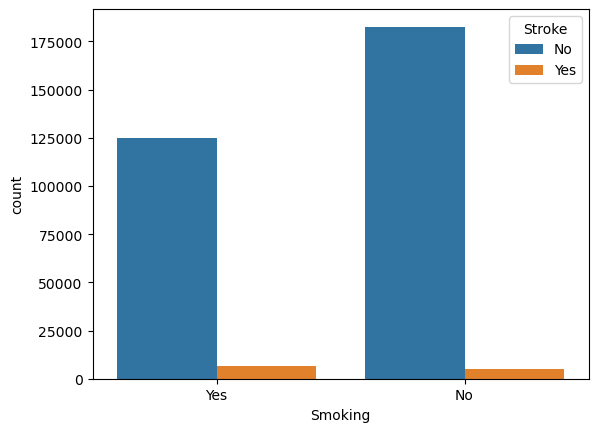

Stroke,No,Yes
Smoking,,
No,0.972036,0.027964
Yes,0.948335,0.051665


In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Smoking", hue="Stroke", data=df)
plt.show()

pd.crosstab(df["Smoking"], df["Stroke"], normalize="index")

HeartDisease vs Stroke

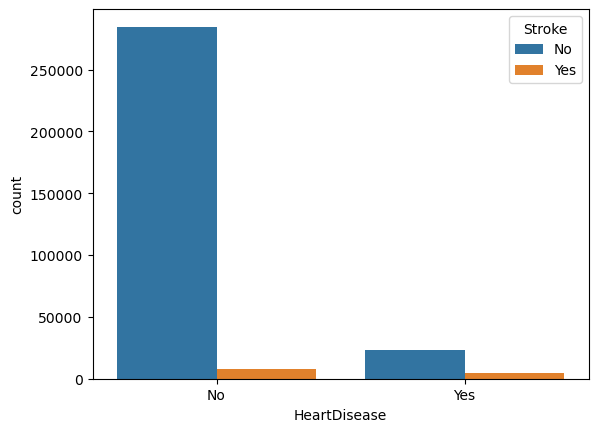

Stroke,No,Yes
HeartDisease,,
No,0.973737,0.026263
Yes,0.839660,0.160340


In [32]:
sns.countplot(x="HeartDisease", hue="Stroke", data=df)
plt.show()

pd.crosstab(df["HeartDisease"], df["Stroke"], normalize="index")

Diabetic vs Stroke

In [33]:
pd.crosstab(df["Diabetic"], df["Stroke"], normalize="index")

Stroke,No,Yes
Diabetic,,
No,0.970707,0.029293
"No, borderline diabetes",0.947795,0.052205
Yes,0.908240,0.091760
Yes (during pregnancy),0.971864,0.028136


AgeCategory vs Stroke

In [34]:
pd.crosstab(df["AgeCategory"], df["Stroke"], normalize="index")

Stroke,No,Yes
AgeCategory,,
18-24,0.997104,0.002896
25-29,0.994692,0.005308
30-34,0.993014,0.006986
35-39,0.990608,0.009392
40-44,0.986052,0.013948
45-49,0.980359,0.019641
50-54,0.973012,0.026988
55-59,0.963000,0.037000
60-64,0.955976,0.044024


GenHealth vs Stroke

In [35]:
pd.crosstab(df["GenHealth"], df["Stroke"], normalize="index")

Stroke,No,Yes
GenHealth,,
Excellent,0.989662,0.010338
Fair,0.904894,0.095106
Good,0.958348,0.041652
Poor,0.829126,0.170874
Very good,0.980045,0.019955


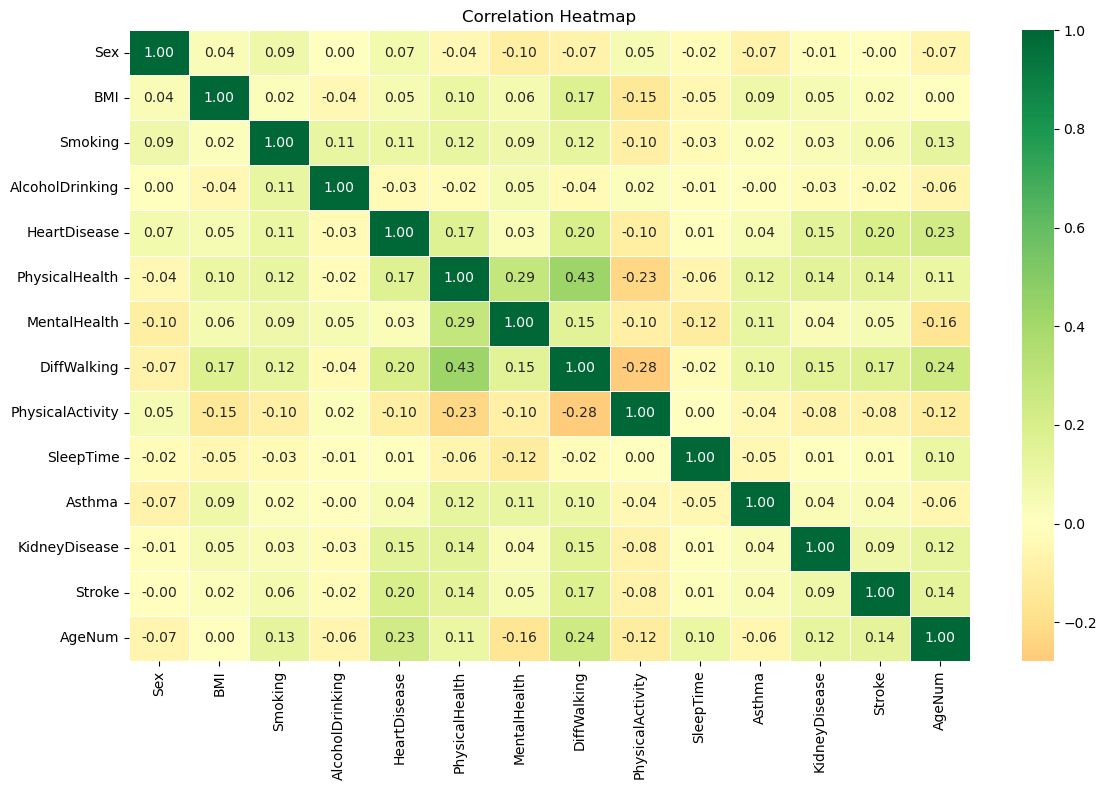

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

# محتاج نحول الـ target وبعض الأعمدة لأرقام مؤقتاً
df_corr = df.copy()

# تحويل Yes/No لـ 0/1
binary_cols = ["Sex", "Smoking", "AlcoholDrinking", "HeartDisease",
               "DiffWalking", "PhysicalActivity", "Asthma",
               "KidneyDisease", "Stroke"]

for col in binary_cols:
    df_corr[col] = df_corr[col].map({"Yes": 1, "No": 0,
                                      "Male": 1, "Female": 0})

# AgeCategory → رقم مؤقت
age_map = {"18-24":1,"25-29":2,"30-34":3,"35-39":4,"40-44":5,
           "45-49":6,"50-54":7,"55-59":8,"60-64":9,"65-69":10,
           "70-74":11,"75-79":12,"80 or older":13}
df_corr["AgeNum"] = df_corr["AgeCategory"].map(age_map)

# اختار الأعمدة الرقمية بس
numeric_df = df_corr.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(12, 8))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [37]:
# age numeric
age_map = {
    "18-24": 1,
    "25-29": 2,
    "30-34": 3,
    "35-39": 4,
    "40-44": 5,
    "45-49": 6,
    "50-54": 7,
    "55-59": 8,
    "60-64": 9,
    "65-69": 10,
    "70-74": 11,
    "75-79": 12,
    "80 or older": 13
}
df["AgeNum"] = df["AgeCategory"].map(age_map)

# diabetic flag
df["is_diabetic"] = df["Diabetic"].isin(
    ["Yes", "No, borderline diabetes"]
).astype(int)

# health flag
df["bad_health"] = df["GenHealth"].isin(
    ["Poor", "Fair"]
).astype(int)

# risk score
df["risk_score"] = (
    df["HeartDisease"].map({"Yes":1,"No":0}) +
    df["is_diabetic"] +
    df["bad_health"]
)

In [38]:
df.columns

Index(['Sex', 'BMI', 'Smoking', 'AlcoholDrinking', 'HeartDisease',
       'PhysicalHealth', 'MentalHealth', 'DiffWalking', 'Diabetic',
       'AgeCategory', 'Race', 'PhysicalActivity', 'GenHealth', 'SleepTime',
       'Asthma', 'KidneyDisease', 'Stroke', 'AgeNum', 'is_diabetic',
       'bad_health', 'risk_score'],
      dtype='object')

In [39]:
df = df.drop("AgeCategory", axis=1)
df = df.drop("Diabetic", axis=1)
df = df.drop("GenHealth", axis=1)
df = df.drop("AlcoholDrinking", axis=1)   
df = df.drop("SleepTime", axis=1)          
df = df.drop("DiffWalking", axis=1) 

Encoding

In [40]:
df = pd.get_dummies(df, drop_first=True)

In [41]:
df.shape
df.head()

,BMI,PhysicalHealth,MentalHealth,AgeNum,is_diabetic,bad_health,risk_score,Sex_Male,Smoking_Yes,HeartDisease_Yes,Race_Asian,Race_Black,Race_Hispanic,Race_Other,Race_White,PhysicalActivity_Yes,Asthma_Yes,KidneyDisease_Yes,Stroke_Yes
0,16.60,3,30,8,1,0,1,False,True,False,False,False,False,False,True,True,True,False,False
1,20.34,0,0,13,0,0,0,False,False,False,False,False,False,False,True,True,False,False,True
2,26.58,20,30,10,1,1,2,True,True,False,False,False,False,False,True,True,True,False,False
3,24.21,0,0,12,0,0,0,False,False,False,False,False,False,False,True,False,False,False,False
4,23.71,28,0,5,0,0,0,False,False,False,False,False,False,False,True,True,False,False,False


Split

In [42]:
from sklearn.model_selection import train_test_split

X = df.drop("Stroke_Yes", axis=1)
y = df["Stroke_Yes"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [43]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [44]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight="balanced", max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

In [45]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[46616 14929]
 [  675  1739]]
              precision    recall  f1-score   support

       False       0.99      0.76      0.86     61545
        True       0.10      0.72      0.18      2414

    accuracy                           0.76     63959
   macro avg       0.55      0.74      0.52     63959
weighted avg       0.95      0.76      0.83     63959



In [46]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    class_weight="balanced",
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[60237  1308]
 [ 2328    86]]
              precision    recall  f1-score   support

       False       0.96      0.98      0.97     61545
        True       0.06      0.04      0.05      2414

    accuracy                           0.94     63959
   macro avg       0.51      0.51      0.51     63959
weighted avg       0.93      0.94      0.94     63959



SMOTE

In [47]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)

X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print(y_train_sm.value_counts())

Stroke_Yes
False    246181
True     246181
Name: count, dtype: int64


In [48]:
rf_sm = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_sm.fit(X_train_sm, y_train_sm)

y_pred = rf_sm.predict(X_test)


from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[57299  4246]
 [ 1995   419]]
              precision    recall  f1-score   support

       False       0.97      0.93      0.95     61545
        True       0.09      0.17      0.12      2414

    accuracy                           0.90     63959
   macro avg       0.53      0.55      0.53     63959
weighted avg       0.93      0.90      0.92     63959



threshold

In [49]:
y_probs = rf.predict_proba(X_test)[:,1]

In [50]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

for t in [0.1, 0.2, 0.3, 0.4, 0.5]:
    print("\nThreshold =", t)
    y_pred_t = (y_probs >= t).astype(int)
    print(confusion_matrix(y_test, y_pred_t))
    print(classification_report(y_test, y_pred_t))


Threshold = 0.1
[[54397  7148]
 [ 1511   903]]
              precision    recall  f1-score   support

       False       0.97      0.88      0.93     61545
        True       0.11      0.37      0.17      2414

    accuracy                           0.86     63959
   macro avg       0.54      0.63      0.55     63959
weighted avg       0.94      0.86      0.90     63959


Threshold = 0.2
[[57586  3959]
 [ 1917   497]]
              precision    recall  f1-score   support

       False       0.97      0.94      0.95     61545
        True       0.11      0.21      0.14      2414

    accuracy                           0.91     63959
   macro avg       0.54      0.57      0.55     63959
weighted avg       0.94      0.91      0.92     63959


Threshold = 0.3
[[58805  2740]
 [ 2130   284]]
              precision    recall  f1-score   support

       False       0.97      0.96      0.96     61545
        True       0.09      0.12      0.10      2414

    accuracy                          

In [51]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

xgb_model.fit(X_train_sm, y_train_sm)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

In [52]:
y_pred = xgb_model.predict(X_test)

from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[49779 11766]
 [ 1166  1248]]
              precision    recall  f1-score   support

       False       0.98      0.81      0.89     61545
        True       0.10      0.52      0.16      2414

    accuracy                           0.80     63959
   macro avg       0.54      0.66      0.52     63959
weighted avg       0.94      0.80      0.86     63959



In [53]:
y_probs = xgb_model.predict_proba(X_test)[:,1]

from sklearn.metrics import confusion_matrix, classification_report

for t in [0.1, 0.2, 0.3, 0.4, 0.5]:
    print("\nThreshold =", t)
    y_pred_t = (y_probs >= t).astype(int)
    print(confusion_matrix(y_test, y_pred_t))
    print(classification_report(y_test, y_pred_t))


Threshold = 0.1
[[21520 40025]
 [  167  2247]]
              precision    recall  f1-score   support

       False       0.99      0.35      0.52     61545
        True       0.05      0.93      0.10      2414

    accuracy                           0.37     63959
   macro avg       0.52      0.64      0.31     63959
weighted avg       0.96      0.37      0.50     63959


Threshold = 0.2
[[31463 30082]
 [  377  2037]]
              precision    recall  f1-score   support

       False       0.99      0.51      0.67     61545
        True       0.06      0.84      0.12      2414

    accuracy                           0.52     63959
   macro avg       0.53      0.68      0.40     63959
weighted avg       0.95      0.52      0.65     63959


Threshold = 0.3
[[38662 22883]
 [  605  1809]]
              precision    recall  f1-score   support

       False       0.98      0.63      0.77     61545
        True       0.07      0.75      0.13      2414

    accuracy                          

In [54]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

xgb_base = XGBClassifier(
    eval_metric="logloss",
    n_jobs=-1,
    random_state=42
)

param_grid = {
    "n_estimators": [200, 400, 600],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1],
    "colsample_bytree": [0.7, 0.8, 1],
    "gamma": [0, 1, 2],
    "min_child_weight": [1, 3, 5]
}

search = RandomizedSearchCV(
    xgb_base,
    param_grid,
    n_iter=10,
    scoring="f1",
    cv=3,
    verbose=1,
    n_jobs=-1
)

search.fit(X_train_sm, y_train_sm)

best_xgb = search.best_estimator_
_

Fitting 3 folds for each of 10 candidates, totalling 30 fits


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

In [55]:
from catboost import CatBoostClassifier

# CatBoost + scale_pos_weight
scale = (y_train == False).sum() / (y_train == True).sum()

cat_model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale,
    random_seed=42,
    verbose=0
)
cat_model.fit(X_train, y_train)

y_pred = cat_model.predict(X_test)
print("CatBoost + scale_pos_weight")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

CatBoost + scale_pos_weight
[[45386 16159]
 [  660  1754]]
              precision    recall  f1-score   support

       False       0.99      0.74      0.84     61545
        True       0.10      0.73      0.17      2414

    accuracy                           0.74     63959
   macro avg       0.54      0.73      0.51     63959
weighted avg       0.95      0.74      0.82     63959



In [56]:
# CatBoost + SMOTE
cat_sm = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.1,
    random_seed=42,
    verbose=0
)
cat_sm.fit(X_train_sm, y_train_sm)

y_pred = cat_sm.predict(X_test)
print("CatBoost + SMOTE")
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

CatBoost + SMOTE
[[50487 11058]
 [ 1205  1209]]
              precision    recall  f1-score   support

       False       0.98      0.82      0.89     61545
        True       0.10      0.50      0.16      2414

    accuracy                           0.81     63959
   macro avg       0.54      0.66      0.53     63959
weighted avg       0.94      0.81      0.86     63959



In [57]:
y_probs = best_xgb.predict_proba(X_test)[:,1]

In [58]:
from sklearn.metrics import confusion_matrix, classification_report

for t in [0.1, 0.2, 0.3, 0.4, 0.5]:
    print("\nThreshold =", t)

    y_pred_t = (y_probs >= t).astype(int)

    print(confusion_matrix(y_test, y_pred_t))
    print(classification_report(y_test, y_pred_t))


Threshold = 0.1
[[25105 36440]
 [  282  2132]]
              precision    recall  f1-score   support

       False       0.99      0.41      0.58     61545
        True       0.06      0.88      0.10      2414

    accuracy                           0.43     63959
   macro avg       0.52      0.65      0.34     63959
weighted avg       0.95      0.43      0.56     63959


Threshold = 0.2
[[34453 27092]
 [  529  1885]]
              precision    recall  f1-score   support

       False       0.98      0.56      0.71     61545
        True       0.07      0.78      0.12      2414

    accuracy                           0.57     63959
   macro avg       0.52      0.67      0.42     63959
weighted avg       0.95      0.57      0.69     63959


Threshold = 0.3
[[41089 20456]
 [  786  1628]]
              precision    recall  f1-score   support

       False       0.98      0.67      0.79     61545
        True       0.07      0.67      0.13      2414

    accuracy                          

In [59]:
print(search.best_params_)

{'subsample': 0.7, 'n_estimators': 600, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.8}


Feature Importance

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

importance = best_xgb.feature_importances_

feat_imp = pd.Series(importance, index=X.columns)

feat_imp = feat_imp.sort_values(ascending=False)

print(feat_imp.head(10))

HeartDisease_Yes     0.240729
risk_score           0.090416
Race_Black           0.076159
Smoking_Yes          0.075013
Race_White           0.071900
Race_Hispanic        0.069465
Race_Other           0.069336
Race_Asian           0.050720
AgeNum               0.047704
KidneyDisease_Yes    0.046292
dtype: float32


In [61]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

def evaluate_model(name, model, X=X_test):
    y_pred = model.predict(X)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    return [name, precision, recall, f1, acc]


In [62]:
results = []

results.append(evaluate_model("Logistic", model, X=X_test_scaled))
results.append(evaluate_model("RF", rf))
results.append(evaluate_model("RF_SMOTE", rf_sm))
results.append(evaluate_model("XGB", xgb_model))
results.append(evaluate_model("XGB_Tuned", best_xgb))
results.append(evaluate_model("CatBoost", cat_model))
results.append(evaluate_model("CatBoost_SMOTE", cat_sm))

results

[['Logistic',
  0.10433165346772258,
  0.7203811101905551,
  0.18226600985221675,
  0.7560312074922998],
 ['RF',
  0.06169296987087518,
  0.035625517812758904,
  0.045168067226890755,
  0.943151081161369],
 ['RF_SMOTE',
  0.08981779206859593,
  0.1735708367854184,
  0.11837830202005933,
  0.9024218640066293],
 ['XGB',
  0.0958967266021208,
  0.5169842584921293,
  0.1617837697692507,
  0.7978079707312498],
 ['XGB_Tuned',
  0.09437159932209437,
  0.4382767191383596,
  0.15530275229357798,
  0.8200565987585797],
 ['CatBoost',
  0.09791771339250824,
  0.7265948632974316,
  0.17257834407438383,
  0.737034662830876],
 ['CatBoost_SMOTE',
  0.09855710442651015,
  0.5008285004142502,
  0.1647026769293645,
  0.8082677965571694]]

In [63]:
import pandas as pd

results_df = pd.DataFrame(
    results,
    columns=["Model", "Precision", "Recall", "F1", "Accuracy"]
)

results_df

,Model,Precision,Recall,F1,Accuracy
0,Logistic,0.104332,0.720381,0.182266,0.756031
1,RF,0.061693,0.035626,0.045168,0.943151
2,RF_SMOTE,0.089818,0.173571,0.118378,0.902422
3,XGB,0.095897,0.516984,0.161784,0.797808
4,XGB_Tuned,0.094372,0.438277,0.155303,0.820057
5,CatBoost,0.097918,0.726595,0.172578,0.737035
6,CatBoost_SMOTE,0.098557,0.500829,0.164703,0.808268


save model



In [65]:
import joblib
import os

os.makedirs("models", exist_ok=True)


joblib.dump(cat_model, "models/clinical_model_v1.pkl")

import json
with open("models/feature_columns.json", "w") as f:
    json.dump(list(X.columns), f)

print("  - models/clinical_model_v1.pkl")
print("  - models/feature_columns.json")

  - models/clinical_model_v1.pkl
  - models/feature_columns.json
